In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stellarhalo
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
Npart4 = jsm_ancillary.load_sample("../../data/zhao/ctest/concentration_test_Npart4.h5")
Npart5 = jsm_ancillary.load_sample("../../data/zhao/ctest/concentration_test_Npart5.h5")
Npart6 = jsm_ancillary.load_sample("../../data/zhao/ctest/concentration_test_Npart6.h5")
Npart7 = jsm_ancillary.load_sample("../../data/zhao/ctest/concentration_test_Npart7.h5")

In [5]:
smooth4 = jsm_ancillary.make_matrix(Npart4, "c_measured_smooth")[:, 0]
fixed_COM4 = jsm_ancillary.make_matrix(Npart4, "c_measured_fixed_COM")[:, 0]
shifted_COM4 = jsm_ancillary.make_matrix(Npart4, "c_measured_shifted_COM")[:, 0]

In [6]:
smooth5 = jsm_ancillary.make_matrix(Npart5, "c_measured_smooth")[:, 0]
fixed_COM5 = jsm_ancillary.make_matrix(Npart5, "c_measured_fixed_COM")[:, 0]
shifted_COM5 = jsm_ancillary.make_matrix(Npart5, "c_measured_shifted_COM")[:, 0]

In [7]:
smooth6 = jsm_ancillary.make_matrix(Npart6, "c_measured_smooth")[:, 0]
fixed_COM6 = jsm_ancillary.make_matrix(Npart6, "c_measured_fixed_COM")[:, 0]
shifted_COM6 = jsm_ancillary.make_matrix(Npart6, "c_measured_shifted_COM")[:, 0]

In [8]:
smooth7 = jsm_ancillary.make_matrix(Npart7, "c_measured_smooth")[:, 0]
fixed_COM7 = jsm_ancillary.make_matrix(Npart7, "c_measured_fixed_COM")[:, 0]
shifted_COM7 = jsm_ancillary.make_matrix(Npart7, "c_measured_shifted_COM")[:, 0]

In [9]:
from scipy.stats import binned_statistic

def compute_com_stats(fsub_used, concentration, fsub_min, fsub_max, Nbin):
    """
    Bins log10(fsub_used) into Nbin bins spanning [fsub_min, fsub_max]
    (given as log10 values), and computes:
      - median/std of log10(concentration) within each bin (nan-masked)
      - Ncalc: total number of calculations per bin (including nans)
      - nanfrac: fraction of those calculations that returned nan

    Parameters
    ----------
    fsub_used : array
        Linear (not log) fsub values.
    concentration : array
        Linear (not log) concentration values.
    fsub_min, fsub_max : float
        Log10 bounds on fsub used to define bin edges.
    Nbin : int
        Number of bins.

    Returns
    -------
    bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat
    """
    nanmask = ~np.isnan(concentration)

    log_fsub_all = np.log10(fsub_used)  # unfiltered, for Ncalc/nanfrac
    log_fsub = log_fsub_all[nanmask]
    log_com = np.log10(concentration[nanmask])

    bin_edges = np.linspace(fsub_min, fsub_max, Nbin + 1)

    # median/std computed only from non-nan entries, so binned_statistic
    # never sees a nan and can't propagate one into the result
    median_stat, edges, _ = binned_statistic(
        log_fsub, log_com, statistic="median", bins=bin_edges
    )
    std_stat, _, _ = binned_statistic(
        log_fsub, log_com, statistic="std", bins=bin_edges
    )

    # Ncalc: total number of attempted calculations per bin, nan or not
    Ncalc_stat, _, _ = binned_statistic(
        log_fsub_all, np.ones_like(log_fsub_all), statistic="count", bins=bin_edges
    )

    # nanfrac: fraction of those calculations that returned nan
    nanfrac_stat, _, _ = binned_statistic(
        log_fsub_all, np.isnan(concentration).astype(float),
        statistic="mean", bins=bin_edges
    )

    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    return bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat

In [10]:
# define bin range/count once, apply consistently across all datasets
fsub_min, fsub_max, Nbin = -3, -1, 15

datasets = {
    "N$_{\\rm particles}$ = 1e4": (Npart4["fsub_used"], fixed_COM4),
    "N$_{\\rm particles}$ = 1e5": (Npart5["fsub_used"], fixed_COM5),
    "N$_{\\rm particles}$ = 1e6": (Npart6["fsub_used"], fixed_COM6),
    "N$_{\\rm particles}$ = 1e7": (Npart7["fsub_used"], fixed_COM7),
}

stats = {}
for label, (fsub_used, concentration) in datasets.items():
    bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat = compute_com_stats(
        fsub_used, concentration, fsub_min, fsub_max, Nbin
    )
    stats[label] = dict(x=bin_centers, median=median_stat, std=std_stat,
                         Ncalc=Ncalc_stat, nanfrac=nanfrac_stat)

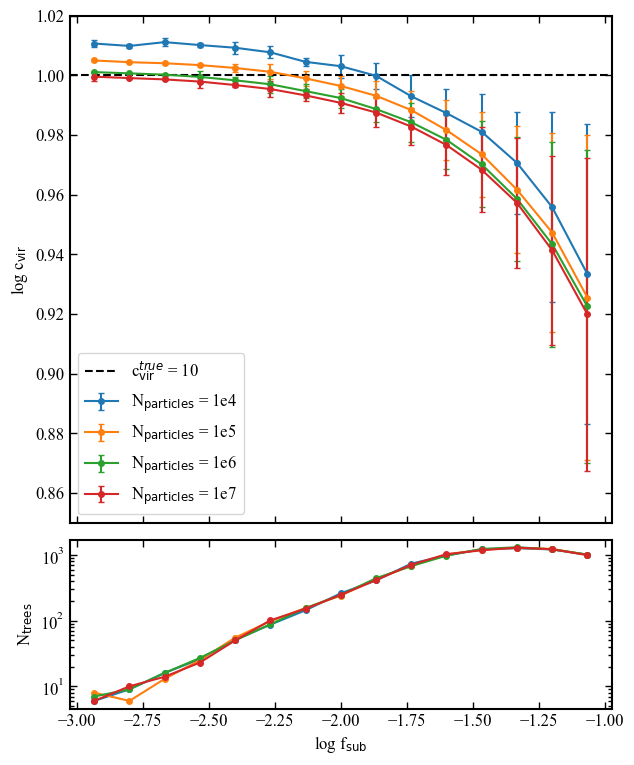

In [11]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(7, 9),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# ax1.set_title("fixed COM")
for label, s in stats.items():
    ax1.errorbar(s["x"], s["median"], yerr=s["std"],
                 label=label, marker="o", ms=4, capsize=2)
    ax2.plot(s["x"], s["Ncalc"], marker="o", ms=4)
    # ax3.plot(s["x"], s["nanfrac"], marker="o", ms=4)

ax1.axhline(1, ls="--", c="k", label="c$_{\\rm vir}^{true}$ = 10")
ax1.set_ylabel("log c$_{\\rm vir}$")
ax1.legend()

ax2.set_yscale("log")
ax2.set_ylabel("N$_{\\rm trees}$")

ax2.set_xlabel("log f$_{\\rm sub}$")
# ax3.set_ylabel("fraction of \nfailed measurements")
# ax3.set_ylim(0, 1)
ax1.set_ylim(0.85, 1.02)

plt.show()

In [12]:
# define bin range/count once, apply consistently across all datasets
fsub_min, fsub_max, Nbin = -3, -0.1, 20

datasets = {
    "N$_{\\rm particles}$ = 1e4": (Npart4["fsub_used"], shifted_COM4),
    "N$_{\\rm particles}$ = 1e5": (Npart5["fsub_used"], shifted_COM5),
    "N$_{\\rm particles}$ = 1e6": (Npart6["fsub_used"], shifted_COM6),
    "N$_{\\rm particles}$ = 1e7": (Npart7["fsub_used"], shifted_COM7),
}

stats = {}
for label, (fsub_used, concentration) in datasets.items():
    bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat = compute_com_stats(
        fsub_used, concentration, fsub_min, fsub_max, Nbin
    )
    stats[label] = dict(x=bin_centers, median=median_stat, std=std_stat,
                         Ncalc=Ncalc_stat, nanfrac=nanfrac_stat)

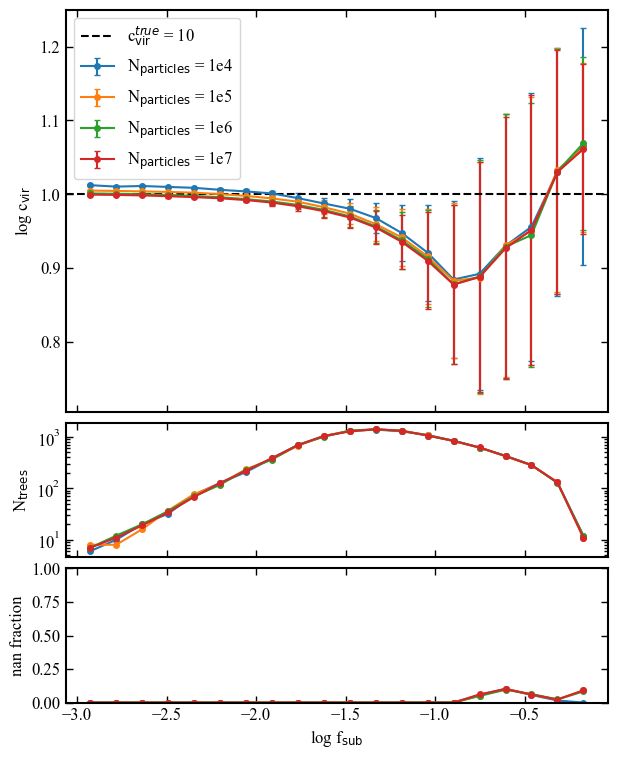

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, sharex=True, figsize=(7, 9),
    gridspec_kw={"height_ratios": [3, 1, 1], "hspace": 0.05}
)

# ax1.set_title("shifted COM")
for label, s in stats.items():
    ax1.errorbar(s["x"], s["median"], yerr=s["std"],
                 label=label, marker="o", ms=4, capsize=2)
    ax2.plot(s["x"], s["Ncalc"], marker="o", ms=4)
    ax3.plot(s["x"], s["nanfrac"], marker="o", ms=4)

ax1.axhline(1, ls="--", c="k", label="c$_{\\rm vir}^{true}$ = 10")
ax1.set_ylabel("log c$_{\\rm vir}$")
ax1.legend()
# ax1.set_ylim(0.85, 1.02)

ax2.set_yscale("log")
ax2.set_ylabel("N$_{\\rm trees}$")

ax3.set_xlabel("log f$_{\\rm sub}$")
ax3.set_ylabel("nan fraction")
ax3.set_ylim(0, 1)

plt.show()

In [14]:
from scipy.stats import binned_statistic

def compute_Nsub_stats(Nsub_used, concentration, Nsub_min=0, Nsub_max=15):
    """
    Bins Nsub_used into one bin per integer value spanning
    [Nsub_min, Nsub_max], and computes:
      - median/std of log10(concentration) within each bin (nan-masked)
      - Ncalc: total number of calculations per bin (including nans)
      - nanfrac: fraction of those calculations that returned nan

    Parameters
    ----------
    Nsub_used : array
        Integer Nsub values (linear, not log -- Nsub is a count).
    concentration : array
        Linear (not log) concentration values.
    Nsub_min, Nsub_max : int
        Integer bounds on Nsub used to define bin edges.

    Returns
    -------
    bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat
    """
    nanmask = ~np.isnan(concentration)

    Nsub_all = Nsub_used  # unfiltered, for Ncalc/nanfrac -- no log transform, Nsub is a count
    Nsub_masked = Nsub_all[nanmask]
    log_com = np.log10(concentration[nanmask])

    # one bin per integer: edges at half-integers so each Nsub value
    # falls unambiguously into exactly one bin
    bin_edges = np.arange(Nsub_min - 0.5, Nsub_max + 1.5, 1)

    # median/std computed only from non-nan entries, so binned_statistic
    # never sees a nan and can't propagate one into the result
    median_stat, edges, _ = binned_statistic(
        Nsub_masked, log_com, statistic="median", bins=bin_edges
    )
    std_stat, _, _ = binned_statistic(
        Nsub_masked, log_com, statistic="std", bins=bin_edges
    )

    # Ncalc: total number of attempted calculations per bin, nan or not
    Ncalc_stat, _, _ = binned_statistic(
        Nsub_all, np.ones_like(Nsub_all), statistic="count", bins=bin_edges
    )

    # nanfrac: fraction of those calculations that returned nan
    nanfrac_stat, _, _ = binned_statistic(
        Nsub_all, np.isnan(concentration).astype(float),
        statistic="mean", bins=bin_edges
    )

    bin_centers = 0.5 * (edges[:-1] + edges[1:])  # lands exactly on each integer

    return bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat

In [15]:
datasets = {
    "N$_{\\rm particles}$ = 1e4": (Npart4["Nsub_used"], fixed_COM4),
    "N$_{\\rm particles}$ = 1e5": (Npart5["Nsub_used"], fixed_COM5),
    "N$_{\\rm particles}$ = 1e6": (Npart6["Nsub_used"], fixed_COM6),
    "N$_{\\rm particles}$ = 1e7": (Npart7["Nsub_used"], fixed_COM7),
}

stats = {}
for label, (Nsub_used, concentration) in datasets.items():
    bin_centers, median_stat, std_stat, Ncalc_stat, nanfrac_stat = compute_Nsub_stats(
        Nsub_used, concentration
    )
    stats[label] = dict(x=bin_centers, median=median_stat, std=std_stat,
                         Ncalc=Ncalc_stat, nanfrac=nanfrac_stat)

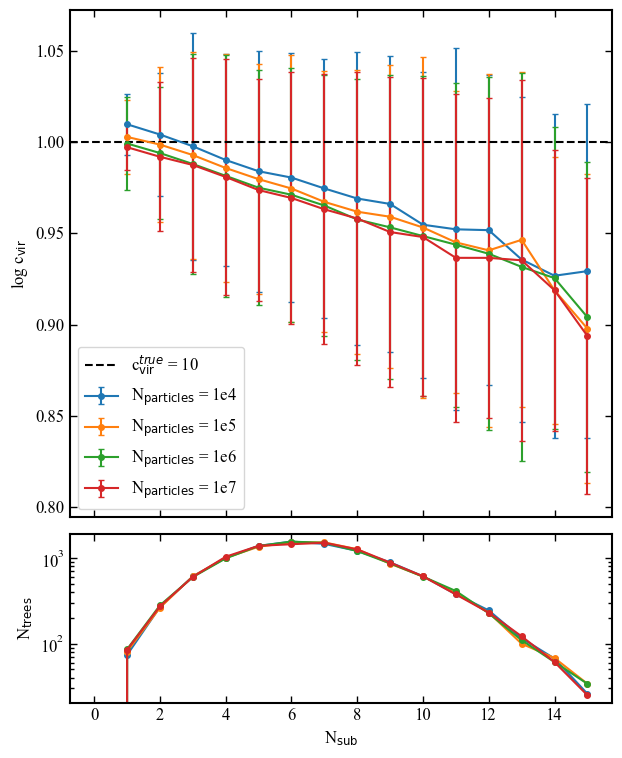

In [16]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(7, 9),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

for label, s in stats.items():
    ax1.errorbar(s["x"], s["median"], yerr=s["std"],
                 label=label, marker="o", ms=4, capsize=2)
    ax2.plot(s["x"], s["Ncalc"], marker="o", ms=4)
    ax3.plot(s["x"], s["nanfrac"], marker="o", ms=4)

ax1.axhline(1, ls="--", c="k", label="c$_{\\rm vir}^{true}$ = 10")
ax1.set_ylabel("log c$_{\\rm vir}$")
ax1.legend()

ax2.set_yscale("log")
ax2.set_ylabel("N$_{\\rm trees}$")

ax2.set_xlabel("N$_{\\rm sub}$")
# ax3.set_ylabel("nan fraction")
# ax3.set_ylim(0, 1)

plt.show()

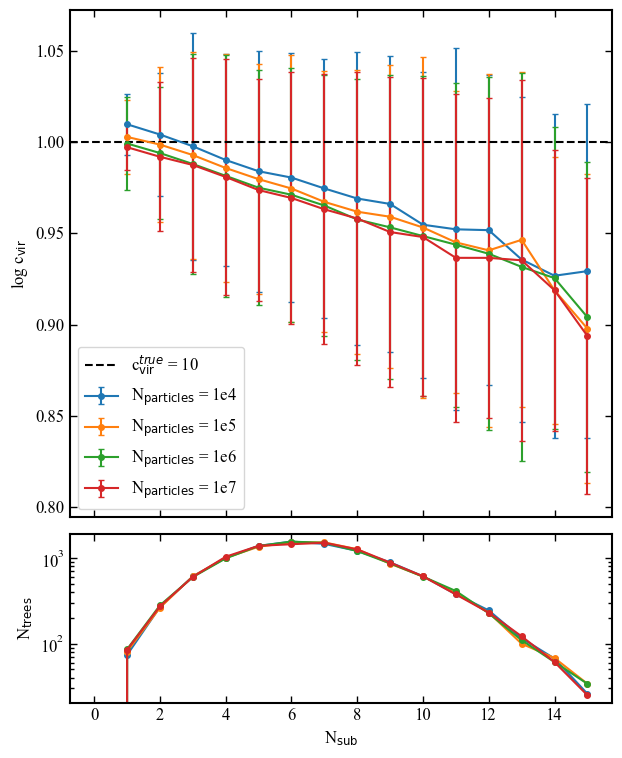

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(7, 9),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

for label, s in stats.items():
    ax1.errorbar(s["x"], s["median"], yerr=s["std"],
                 label=label, marker="o", ms=4, capsize=2)
    ax2.plot(s["x"], s["Ncalc"], marker="o", ms=4)
    ax3.plot(s["x"], s["nanfrac"], marker="o", ms=4)

ax1.axhline(1, ls="--", c="k", label="c$_{\\rm vir}^{true}$ = 10")
ax1.set_ylabel("log c$_{\\rm vir}$")
ax1.legend()

ax2.set_yscale("log")
ax2.set_ylabel("N$_{\\rm trees}$")

ax2.set_xlabel("N$_{\\rm sub}$")
# ax3.set_ylabel("nan fraction")
# ax3.set_ylim(0, 1)

plt.show()

In [17]:
real_cvirs = np.log10(jsm_ancillary.make_matrix(Npart4, "host_c")[:, 0])
z50s = np.log10(1 + Npart4["host_z50"])
fsub = np.log10(Npart4["fsub_used"])
Nsub = np.log10(Npart4["Nsub_used"])

In [18]:
Nsub.min()

0.0

<Axes: xlabel='host_z50', ylabel='fsub_used'>

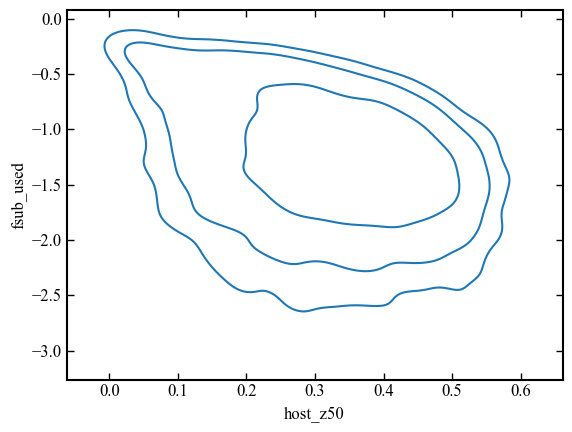

In [19]:
sns.kdeplot(x=z50s, y=fsub, levels=levelz)

<Axes: ylabel='fsub_used'>

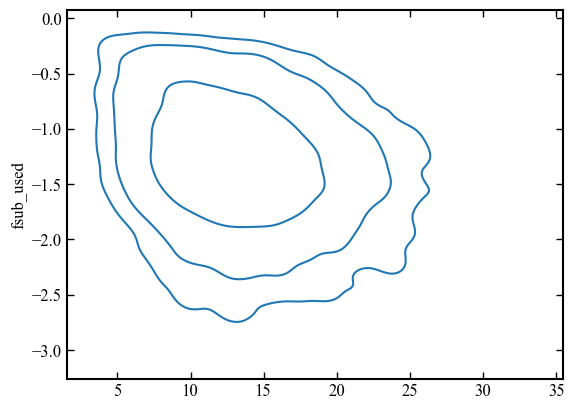

In [20]:
sns.kdeplot(x=jsm_ancillary.make_matrix(Npart4, "host_c")[:, 0], y=np.log10(Npart4["fsub_used"]), levels=levelz)

In [21]:
jsm_stats.correlation(np.log10(1 + Npart4["host_z50"]), np.log10(Npart4["fsub_used"]))

-0.29730989086125237

In [22]:
jsm_ancillary.make_matrix(Npart4, "host_c")[:, 0]

array([14.86443233, 13.73645401, 18.26169777, ...,  9.05418777,
       11.80707169, 17.78351212])